We build a reusable diagnostics engine for a liquid asset.

Metrics:

Simple & log returns
Cumulative performance
Rolling & annualized volatility
Drawdowns
Distribution & tail behavior
Transaction cost sensitivity

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

plt.rcParams["figure.figsize"] = (12,6)
plt.style.use("seaborn-v0_8")

Download Market Data (Code)

We’ll use Apple because it is highly liquid

In [2]:
ticker = "AAPL"
start_date = "2015-01-01"
end_date = "2025-12-31"

data = yf.download(ticker, start=start_date, end=end_date)

data.head()


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.214893,24.682226,23.776353,24.671151,212818400
2015-01-05,23.532722,24.064285,23.346676,23.984551,257142000
2015-01-06,23.534933,23.794069,23.173912,23.596948,263188400
2015-01-07,23.864950,23.964618,23.632391,23.743133,160423600
2015-01-08,24.781893,24.839479,24.075357,24.192745,237458000


We use Adjusted Close because it accounts for splits and dividends.

In [3]:
# ================================
# Robust extraction
# ================================

# Vérifie si les colonnes du DataFrame sont un MultiIndex
# (cas typique quand plusieurs tickers sont téléchargés avec yfinance)
if isinstance(data.columns, pd.MultiIndex):

    # Si la colonne ('Adj Close', ticker) existe,
    # on privilégie "Adj Close" car elle inclut dividendes et splits
    if ('Adj Close', ticker) in data.columns:
        prices = data[('Adj Close', ticker)].copy()  # Extraction propre de la série
        price_field = "Adj Close"  # On mémorise le champ utilisé
    else:
        # Sinon on prend simplement le prix de clôture non ajusté
        prices = data[('Close', ticker)].copy()
        price_field = "Close"

else:
    # Cas où les colonnes sont simples (un seul ticker téléchargé)
    
    # On vérifie si "Adj Close" existe dans les colonnes
    if "Adj Close" in data.columns:
        prices = data["Adj Close"].copy()  # Extraction du prix ajusté
        price_field = "Adj Close"
    else:
        # Sinon on utilise le prix de clôture standard
        prices = data["Close"].copy()
        price_field = "Close"

# Force la structure en pandas Series (évite d'avoir un DataFrame 1-colonne)
# et supprime les valeurs manquantes pour éviter des erreurs plus tard
prices = prices.squeeze().dropna()

# Affiche quel champ a été utilisé (Adj Close ou Close)
print("Using:", price_field)

# Vérifie que l'objet final est bien une Series
print(type(prices))


Using: Close
<class 'pandas.core.series.Series'>


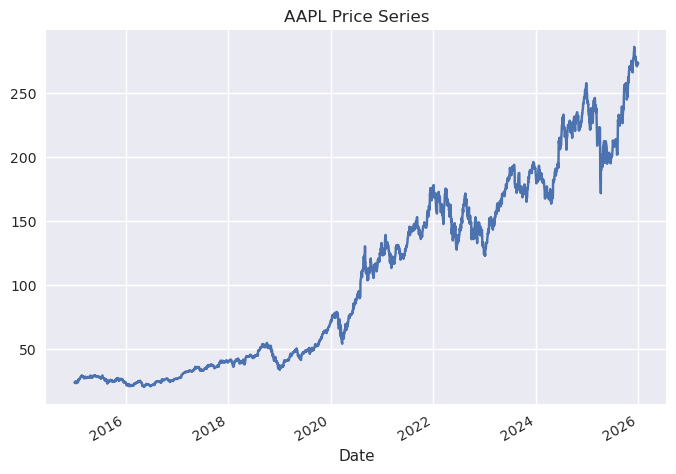

In [4]:
prices.plot(title=f"{ticker} Price Series")
plt.show()

Simple Return = (P_t / P_{t-1}) - 1
Log Return = ln(P_t / P_{t-1})

In [5]:
simple_returns = prices.pct_change()
log_returns = np.log(prices / prices.shift(1))

In [6]:
returns = pd.concat([simple_returns, log_returns], axis=1)
returns.columns = ["simple", "log"]
returns = returns.dropna()

returns.head()

,simple,log
Date,,
2015-01-05,-0.028172,-0.028576
2015-01-06,0.000094,0.000094
2015-01-07,0.014022,0.013925
2015-01-08,0.038422,0.037702
2015-01-09,0.001073,0.001072


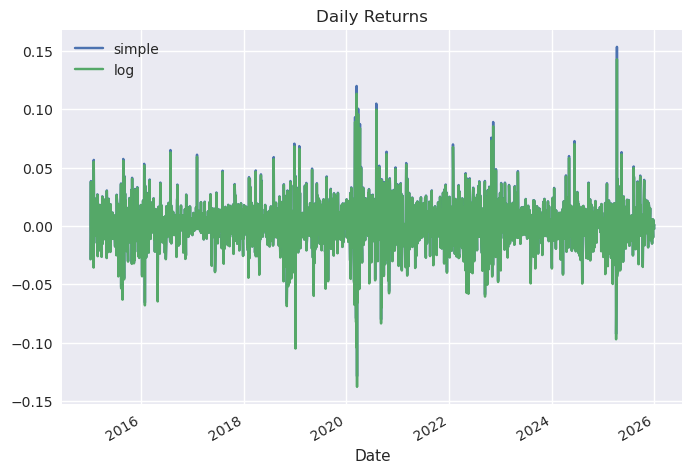

In [7]:
returns.plot(title="Daily Returns")
plt.show()

Cumulative Growth of $1

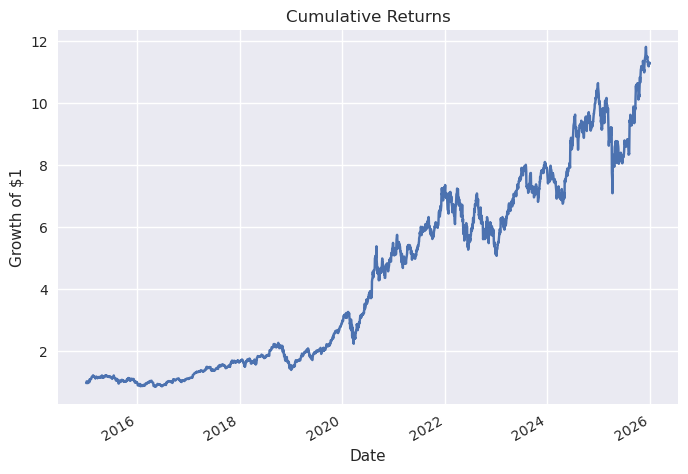

In [8]:
cumulative_returns = (1 + returns["simple"]).cumprod()

cumulative_returns.plot(title="Cumulative Returns")
plt.ylabel("Growth of $1")
plt.show()


RISK VIEW

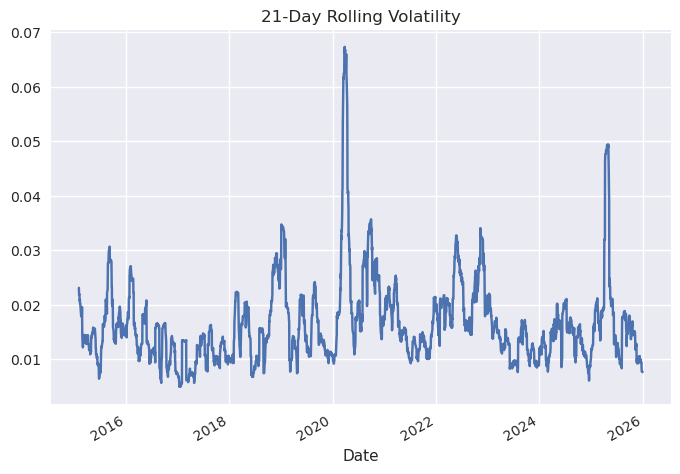

In [9]:
# Rolling Volatility (21 days)
rolling_vol = returns["log"].rolling(21).std()

rolling_vol.plot(title="21-Day Rolling Volatility")
plt.show()

In [10]:
# Annualized Volatility
annualized_vol = returns["log"].std() * np.sqrt(252)
print("Annualized Volatility:", round(float(annualized_vol), 4))

Annualized Volatility: 0.2882


In [11]:
# Drawdowns
cum = (1 + returns["simple"]).cumprod()
running_max = cum.cummax()
drawdown = cum / running_max - 1

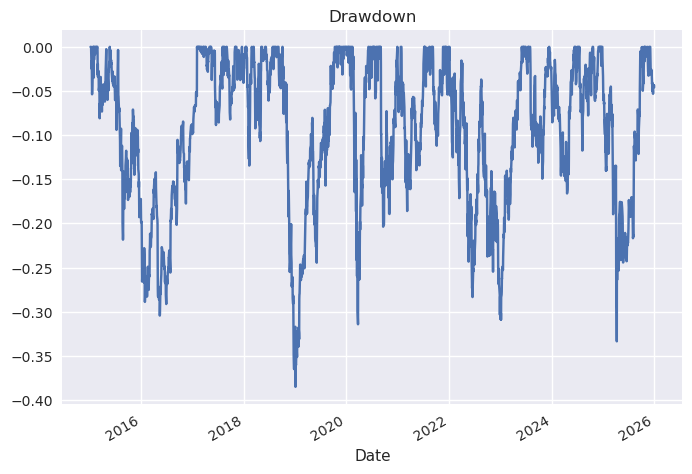

In [12]:
drawdown.plot(title="Drawdown")
plt.show()

Worst Loss From Peak

In [13]:
max_dd = drawdown.min()
print("Maximum Drawdown:", round(float(max_dd), 4))

Maximum Drawdown: -0.3852


In [ ]:
DISTRIBUTION

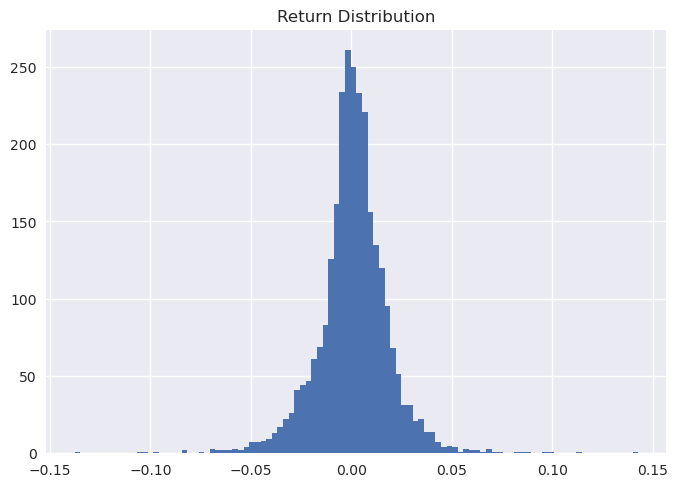

In [14]:
# Histogram
plt.hist(returns["log"], bins=100)
plt.title("Return Distribution")
plt.show()

In [15]:
# Tail Events
print("Worst 5 days")
print(returns["log"].nsmallest(5))

print("\nBest 5 days")
print(returns["log"].nlargest(5))

Worst 5 days
Date
2020-03-16   -0.137708
2019-01-03   -0.104924
2020-03-12   -0.103978
2025-04-03   -0.097013
2020-09-03   -0.083448
Name: log, dtype: float64

Best 5 days
Date
2025-04-09    0.142617
2020-03-13    0.113158
2020-07-31    0.099563
2020-03-24    0.095606
2020-03-02    0.089019
Name: log, dtype: float64


In [16]:
# Volatility Spikes
print(rolling_vol.sort_values(ascending=False).head(10))

Date
2020-03-26    0.067330
2020-03-30    0.066774
2020-03-24    0.066513
2020-03-27    0.066390
2020-03-25    0.066258
2020-04-06    0.065987
2020-04-01    0.063943
2020-04-07    0.063578
2020-03-31    0.063345
2020-04-02    0.063028
Name: log, dtype: float64


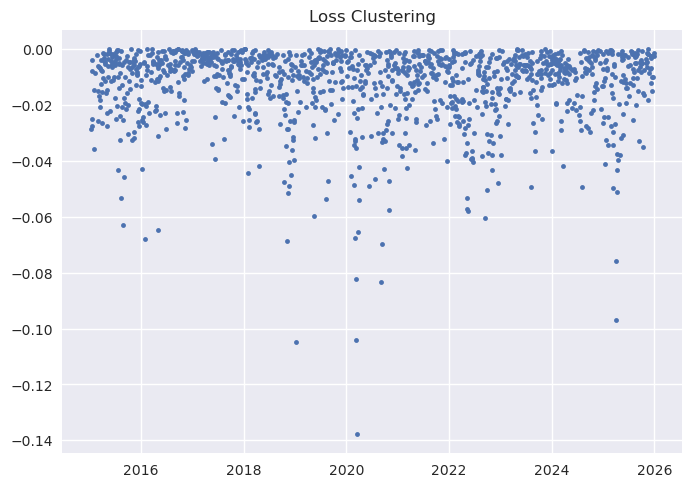

In [17]:
# Loss Clustering
loss_days = returns["log"][returns["log"] < 0]

plt.plot(loss_days.index, loss_days.values, ".")
plt.title("Loss Clustering")
plt.show()

In [18]:
# Upside vs Downside
print("Mean positive:", returns["log"][returns["log"] > 0].mean())
print("Mean negative:", returns["log"][returns["log"] < 0].mean())

Mean positive: 0.012643941389586206
Mean negative: -0.01255025793766206


TRANSACTION COST IMPACT

Assume 5 bps per trade.

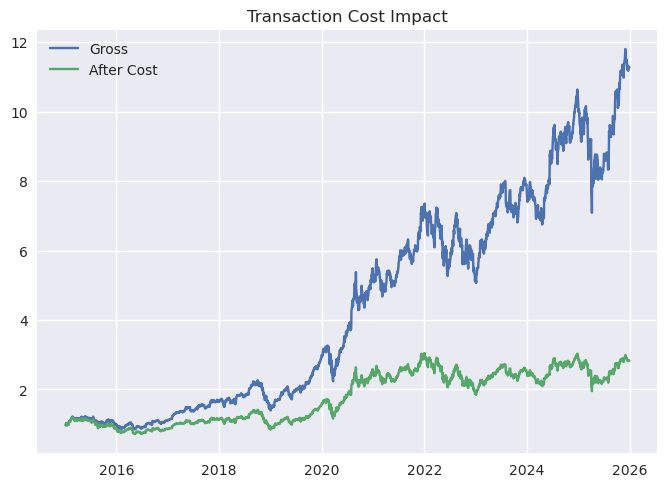

In [19]:
cost = 0.0005

net_returns = returns["simple"] - cost
net_cum = (1 + net_returns).cumprod()

plt.plot(cumulative_returns, label="Gross")
plt.plot(net_cum, label="After Cost")
plt.legend()
plt.title("Transaction Cost Impact")
plt.show()


In [20]:
summary = {
    "Average Daily Return": returns["log"].mean(),
    "Daily Volatility": returns["log"].std(),
    "Annualized Volatility": annualized_vol,
    "Max Drawdown": max_dd
}

for k, v in summary.items():
    print(k, ":", round(float(v), 6))


Average Daily Return : 0.000876
Daily Volatility : 0.018157
Annualized Volatility : 0.288239
Max Drawdown : -0.385159
